In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

In [13]:
# STEP 1: DOWNLOAD & LOAD DATASET
# -------------------------------------------------------------------------
print("--- Downloading and Loading Dataset ---")
import kagglehub

# Download latest version of the Lichess dataset
path = kagglehub.dataset_download("datasnaek/chess")
print("Dataset directory path:", path)

# Locate the CSV file inside the downloaded directory
csv_file_path = os.path.join(path, "games.csv")
df = pd.read_csv(csv_file_path)
print(f"Dataset successfully loaded! Shape: {df.shape}\n")

# Display basic structural breakdown
print(df.info())

--- Downloading and Loading Dataset ---
Dataset directory path: /kaggle/input/datasets/datasnaek/chess
Dataset successfully loaded! Shape: (20058, 16)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name  

In [14]:
# -------------------------------------------------------------------------
# STEP 2: FEATURE ENGINEERING
# -------------------------------------------------------------------------
print("\n--- Starting Feature Engineering ---")

# Feature 1: Rating Difference (White Rating minus Black Rating)
# Represents the core skill advantage of one player over another
df['rating_diff'] = df['white_rating'] - df['black_rating']

# Feature 2: Parsing Time Controls
# Extracts Base Time and Increment seconds from strings like '10+5' or '15+0'
def parse_time_controls(increment_string):
    try:
        parts = str(increment_string).split('+')
        base_time = float(parts[0])
        increment = float(parts[1]) if len(parts) > 1 else 0.0
        return base_time, increment
    except ValueError:
        return 0.0, 0.0

df['base_time'], df['time_increment'] = zip(*df['increment_code'].apply(parse_time_controls))

# Feature 3: Frequency Encoding for High-Cardinality Categorical Values
# Reduces hundreds of unique text strings into manageable numerical frequencies
opening_frequency = df['opening_name'].value_counts().to_dict()
df['opening_name_encoded'] = df['opening_name'].map(opening_frequency)

eco_frequency = df['opening_eco'].value_counts().to_dict()
df['opening_eco_encoded'] = df['opening_eco'].map(eco_frequency)

# Handle Missing Value Failsafes
df = df.dropna(subset=['winner', 'turns'])

print("Feature engineering successfully completed.\n")


--- Starting Feature Engineering ---
Feature engineering successfully completed.



--- Initializing Classification Task (Predicting Winner) ---

Classification Report:
              precision    recall  f1-score   support

       black       0.63      0.60      0.62      1822
        draw       1.00      0.03      0.05       190
       white       0.64      0.72      0.67      2000

    accuracy                           0.63      4012
   macro avg       0.75      0.45      0.45      4012
weighted avg       0.65      0.63      0.62      4012



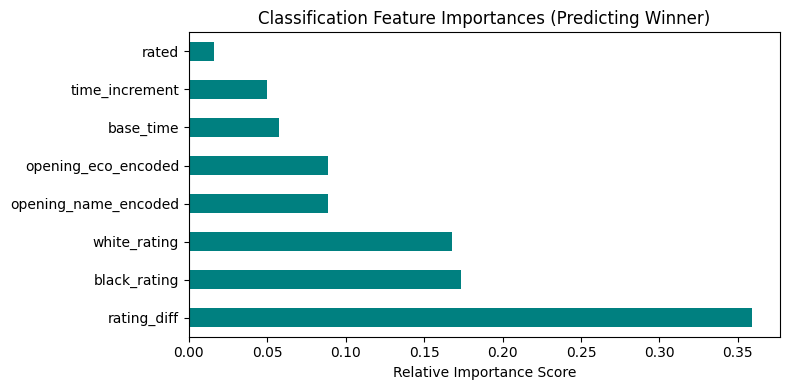

In [15]:
# STEP 3: CLASSIFICATION MODEL (Predicting the Match Winner)
# -------------------------------------------------------------------------
print("--- Initializing Classification Task (Predicting Winner) ---")

# Define classification features and target variables
# We drop post-match leakages like 'turns', 'victory_status', 'moves'
classification_features = [
    'rated', 'white_rating', 'black_rating', 'rating_diff', 
    'base_time', 'time_increment', 'opening_name_encoded', 'opening_eco_encoded'
]

X_class = df[classification_features].copy()
y_class = df['winner']  # Classes: 'white', 'black', 'draw'

# Encode Boolean and Object types to clean numerical formats
X_class['rated'] = X_class['rated'].astype(int)

# Encode categorical Target classes (white=2, black=0, draw=1 depending on alphabetization)
label_encoder_y = LabelEncoder()
y_class_encoded = label_encoder_y.fit_transform(y_class)

# Train-Test Split (80% Train, 20% Test)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class_encoded, test_size=0.2, random_state=42, stratify=y_class_encoded
)

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=12)
rf_classifier.fit(X_train_c, y_train_c)

# Generate Predictions
y_pred_c = rf_classifier.predict(X_test_c)

# Classification Model Evaluation Metrics
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=label_encoder_y.classes_))

# Visualize Feature Importance for Classification
class_importances = pd.Series(rf_classifier.feature_importances_, index=classification_features)
plt.figure(figsize=(8, 4))
class_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Classification Feature Importances (Predicting Winner)')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()


--- Initializing Regression Task (Predicting Match Duration) ---

Regression Metrics (Target: Game Turns):
Mean Absolute Error (MAE)  : 24.90 turns
Root Mean Squared Error (RMSE): 31.67 turns
R-squared Score (R²)       : 0.1101


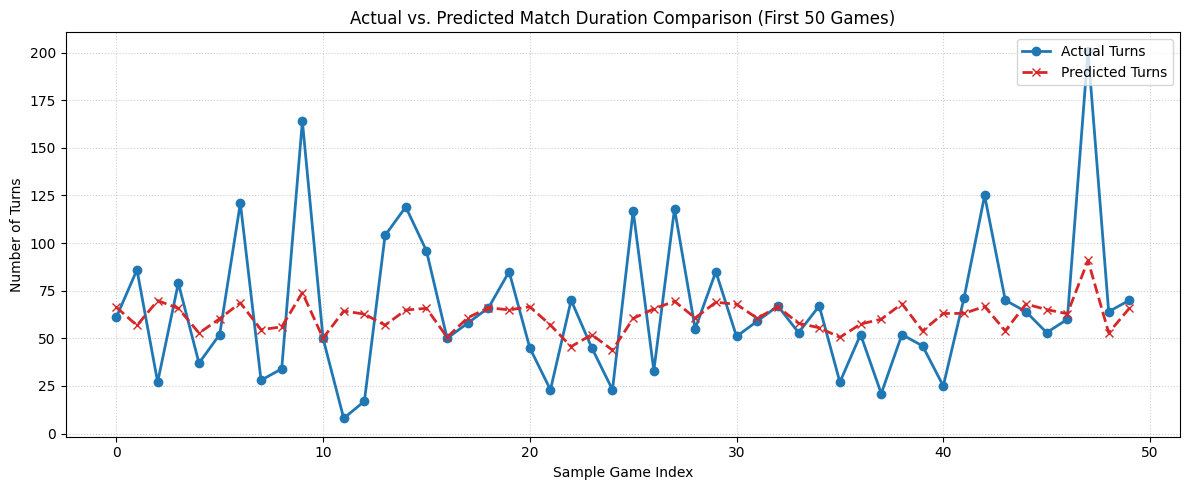


--- Project Pipeline Execution Finished Successfully ---


In [16]:
# -------------------------------------------------------------------------
# STEP 4: REGRESSION MODEL (Predicting Total Match Turns) - UPDATED PLOT
# -------------------------------------------------------------------------
print("\n--- Initializing Regression Task (Predicting Match Duration) ---")

# Feature combination
regression_features = classification_features + ['winner_encoded']
X_reg = X_class.copy()
X_reg['winner_encoded'] = y_class_encoded

y_reg = df['turns']  # Target numerical metric

# Train-Test Split (80% Train, 20% Test)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_regressor.fit(X_train_r, y_train_r)

# Generate Numerical Predictions
y_pred_r = rf_regressor.predict(X_test_r)

# Regression Model Evaluation Metrics
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print(f"\nRegression Metrics (Target: Game Turns):")
print(f"Mean Absolute Error (MAE)  : {mae:.2f} turns")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} turns")
print(f"R-squared Score (R²)       : {r2:.4f}")

# --- NEW VISUALIZATION: SEPARATE COLORS FOR ACTUAL AND PREDICTED VALUES ---
# We take a sample of the first 50 games from the test set for a clean visual comparison
sample_size = 50
game_index = np.arange(sample_size)

# Convert y_test_r to a numpy array to ensure clean slice parsing
y_test_sample = np.array(y_test_r)[:sample_size]
y_pred_sample = y_pred_r[:sample_size]

plt.figure(figsize=(12, 5))

# Plot Actual Turns in Blue
plt.plot(game_index, y_test_sample, label='Actual Turns', 
         color='#1f77b4', marker='o', markersize=6, linewidth=2)

# Plot Predicted Turns in Red
plt.plot(game_index, y_pred_sample, label='Predicted Turns', 
         color='#d62728', marker='x', markersize=6, linestyle='--', linewidth=2)

plt.title(f'Actual vs. Predicted Match Duration Comparison (First {sample_size} Games)')
plt.xlabel('Sample Game Index')
plt.ylabel('Number of Turns')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- Project Pipeline Execution Finished Successfully ---")

In [ ]:
# STEP 1: DOWNLOAD, LOAD & TRAIN MODELS (Executed Once)
# -------------------------------------------------------------------------
print("--- [1/3] Downloading and Loading Dataset ---")
import kagglehub

# Download dataset via kagglehub
path = kagglehub.dataset_download("datasnaek/chess")
csv_file_path = os.path.join(path, "games.csv")
df = pd.read_csv(csv_file_path)
df = df.dropna(subset=['winner', 'turns'])

print("--- [2/3] Engineering Pipeline Features ---")
# Feature processing
df['rating_diff'] = df['white_rating'] - df['black_rating']

def parse_time_controls(increment_string):
    try:
        parts = str(increment_string).split('+')
        return float(parts[0]), (float(parts[1]) if len(parts) > 1 else 0.0)
    except:
        return 0.0, 0.0
        
df['base_time'], df['time_increment'] = zip(*df['increment_code'].apply(parse_time_controls))

# Frequencies for encoding categorical strings
opening_frequency = df['opening_name'].value_counts().to_dict()
df['opening_name_encoded'] = df['opening_name'].map(opening_frequency)

eco_frequency = df['opening_eco'].value_counts().to_dict()
df['opening_eco_encoded'] = df['opening_eco'].map(eco_frequency)
default_eco_encoded = list(eco_frequency.values())[0]

print("--- [3/3] Training Core Machine Learning Models ---")
# Classification Pipeline (Winner)
features = ['rated', 'white_rating', 'black_rating', 'rating_diff', 'base_time', 'time_increment', 'opening_name_encoded', 'opening_eco_encoded']
X_c = df[features].copy()
X_c['rated'] = X_c['rated'].astype(int)

label_encoder_y = LabelEncoder()
y_c = label_encoder_y.fit_transform(df['winner'])

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=12)
rf_classifier.fit(X_c, y_c)

# Regression Pipeline (Turns)
X_r = X_c.copy()
X_r['winner_encoded'] = y_c
y_r = df['turns']

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_regressor.fit(X_r, y_r)

print("\n All models trained and ready!")
print("========================================================")

# -------------------------------------------------------------------------
# STEP 2: PURE PYTHON INTERACTIVE INTERFACE LOOP
# -------------------------------------------------------------------------
while True:
    print("\n--- CHESS PREDICTION SANDBOX (Type 'exit' at any prompt to quit) ---")
    
    try:
        # 1. Gather White Player Rating
        white_input = input("Enter White Player Rating (e.g., 1500): ").strip()
        if white_input.lower() == 'exit': break
        white_rating = int(white_input)
        
        # 2. Gather Black Player Rating
        black_input = input("Enter Black Player Rating (e.g., 1450): ").strip()
        if black_input.lower() == 'exit': break
        black_rating = int(black_input)
        
        # 3. Gather Rated Status
        rated_input = input("Is this a rated match? (yes/no): ").strip().lower()
        if rated_input == 'exit': break
        is_rated = 1 if rated_input in ['yes', 'y'] else 0
        
        # 4. Gather Time Controls
        base_input = input("Enter Base Match Time in Minutes (e.g., 10): ").strip()
        if base_input.lower() == 'exit': break
        base_time = float(base_input)
        
        inc_input = input("Enter Time Increment in Seconds (e.g., 0): ").strip()
        if inc_input.lower() == 'exit': break
        time_increment = float(inc_input)
        
        # 5. Gather Opening Setup
        print("\nPopular openings to try: 'Sicilian Defense', 'French Defense', 'Queen\'s Gambit Declined', 'Ruy Lopez'")
        opening_name = input("Enter Chess Opening Name (Or press Enter for default 'Sicilian Defense'): ").strip()
        if opening_name.lower() == 'exit': break
        if not opening_name:
            opening_name = "Sicilian Defense"
            
    except ValueError:
        print("\n❌ Invalid numerical input detected! Please enter numbers for ratings and times. Let's restart the setup.")
        continue

    # --- LIVE ML INFERENCE PROCESSING ---
    rating_diff = white_rating - black_rating
    encoded_opening_val = opening_frequency.get(opening_name, 1) # Default to 1 if new opening string passed
    
    # Structure input data exactly like the training frame
    match_features_class = pd.DataFrame([{
        'rated': is_rated,
        'white_rating': white_rating,
        'black_rating': black_rating,
        'rating_diff': rating_diff,
        'base_time': base_time,
        'time_increment': time_increment,
        'opening_name_encoded': encoded_opening_val,
        'opening_eco_encoded': default_eco_encoded
    }])
    
    # Predict Winner (Classification)
    winner_encoded_pred = rf_classifier.predict(match_features_class)[0]
    winner_probabilities = rf_classifier.predict_proba(match_features_class)[0]
    winner_label = label_encoder_y.inverse_transform([winner_encoded_pred])[0].upper()
    
    # Predict Match Duration (Regression)
    match_features_reg = match_features_class.copy()
    match_features_reg['winner_encoded'] = winner_encoded_pred
    predicted_turns = rf_regressor.predict(match_features_reg)[0]
    
    # --- DISPLAY METRIC RESULTS ---
    print("\n=============================================")
    print("        LIVE MATCH INFERENCE EVALUATION      ")
    print("=============================================")
    print(f" White ({white_rating}) vs Black ({black_rating})")
    print(f" Settings: Rated={bool(is_rated)} | Time={base_time}+{time_increment} | Opening={opening_name}")
    print("---------------------------------------------")
    print(f" 🏆 PREDICTED WINNER        : {winner_label}")
    print(f" ⏱️  PREDICTED GAME DURATION : {round(predicted_turns)} Total Moves/Turns")
    print("---------------------------------------------")
    print(" Model Confidence Breakdown:")
    for cls_idx, class_name in enumerate(label_encoder_y.classes_):
        prob = winner_probabilities[cls_idx] * 100
        print(f" - {class_name.capitalize()} Probability: {prob:.2f}%")
    print("=============================================\n")
    
    # Ask if they want to run another prediction test
    choice = input("Would you like to predict another match configuration? (y/n): ").strip().lower()
    if choice not in ['y', 'yes']:
        print("\nExiting sandbox script. Happy engineering!")
        break

--- [1/3] Downloading and Loading Dataset ---
--- [2/3] Engineering Pipeline Features ---
--- [3/3] Training Core Machine Learning Models ---

 All models trained and ready!

--- CHESS PREDICTION SANDBOX (Type 'exit' at any prompt to quit) ---


In [ ]:
import joblib
joblib.dump(rf_classifier, 'chess_classifier.pkl')
joblib.dump(rf_regressor, 'chess_regressor.pkl')
print("✅ Files saved successfully to your Kaggle working directory!")